# Per-Strain Transmissibility

This notebook exercises the multiplicative per-strain `TRANSMISSIBILITY`
parameter added to the `abm_2026_03_16` model.

`TRANSMISSIBILITY` scales the per-contact infection probability of the
*transmitting* strain. It defaults to `1.0` (no effect) and may be supplied
either as

- a **scalar**, applied uniformly to every strain, or
- a **per-strain vector** of length `2 ** N_SITES`, indexed by genome
  integer (passed as a hashable `tuple` because `simulate` is `lru_cache`-d).

We run a small condition matrix to confirm the parameter behaves as expected:
a global boost raises overall prevalence, and a per-strain vector reshapes the
competitive balance between strains.


## Environment Setup


In [1]:
%load_ext watermark


In [2]:
import itertools as it

import numpy as np
import pandas as pd
import pylib  # noqa: F401
from pylib.abm_2026_03_16 import simulate
import seaborn as sns
from teeplot import teeplot as tp
from tqdm.auto import tqdm


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
teeplot_subdir = "2026-06-17-strain-transmissibility"


In [4]:
%watermark -diwmuv -iv


Last updated: 2026-06-17T14:40:59.668020+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

pandas : 2.2.3
pylib  : 0.0.0
seaborn: 0.13.2
numpy  : 2.1.2
teeplot: 1.4.2

Watermark: 2.4.3



## Transmissibility Conditions

With `N_SITES = 2` there are `2 ** 2 == 4` strains, indexed by genome integer
`0..3` (bit `s` set means site `s` carries the mutant allele). The vector
conditions below are ordered by genome integer.


In [5]:
CONDITIONS = {
    # scalar: uniform across all strains (model default)
    "uniform (1.0)": 1.0,
    # scalar: global transmissibility boost
    "global boost (1.5)": 1.5,
    # vector: transmissibility rises with mutational load
    "mutant advantage": (1.0, 1.5, 1.5, 2.25),
    # vector: wildtype favored, double-mutant penalized
    "wildtype advantage": (2.0, 1.0, 1.0, 0.5),
}


def transmissibility_caption(T) -> str:
    """Render a condition's transmissibility as a short label."""
    if np.ndim(T) == 0:
        return f"scalar {T}"
    return "vector (" + ", ".join(map(str, T)) + ")"


## Run Condition Matrix


In [6]:
N_REP = 3
N_STEPS = 400
POP_SIZE = 50_000
N_SITES = 2
MUTATION_RATE = 5e-5

frames = []
for (label, TRANSMISSIBILITY), rep in tqdm(
    [*it.product(CONDITIONS.items(), range(N_REP))]
):
    result = simulate(
        N_SITES=N_SITES,
        POP_SIZE=POP_SIZE,
        N_STEPS=N_STEPS,
        MUTATION_RATE=MUTATION_RATE,
        TRANSMISSIBILITY=TRANSMISSIBILITY,
        seed=rep,
    ).copy()
    result["Condition"] = label
    frames.append(result)

df = pd.concat(frames, ignore_index=True).fillna(0)
df.head()


100%|██████████| 12/12 [00:48<00:00,  4.04s/it]


,Step,Seed,Total_Infected,Strain_00,Susc_S0_B0,Susc_S0_B1,Susc_S1_B0,Susc_S1_B1,Strain_10,Strain_01,Strain_11,Condition
0,0,0,0.00022,0.00022,0.99978,0.99978,0.99978,0.99978,0.0,0.0,0.0,uniform (1.0)
1,1,0,0.00030,0.00030,0.99970,0.99970,0.99970,0.99970,0.0,0.0,0.0,uniform (1.0)
2,2,0,0.00042,0.00042,0.99958,0.99958,0.99958,0.99958,0.0,0.0,0.0,uniform (1.0)
3,3,0,0.00058,0.00058,0.99942,0.99942,0.99942,0.99942,0.0,0.0,0.0,uniform (1.0)
4,4,0,0.00072,0.00072,0.99928,0.99928,0.99928,0.99928,0.0,0.0,0.0,uniform (1.0)


## Overall Prevalence Across Conditions

A larger transmissibility multiplier should drive higher overall prevalence.
The median across replicates is shown with a shaded full-range band.


teeplots/2026-06-17-strain-transmissibility/hue=condition+kind=line+viz=relplot+what=total-infected+x=step+y=total-infected+ext=.pdf
teeplots/2026-06-17-strain-transmissibility/hue=condition+kind=line+viz=relplot+what=total-infected+x=step+y=total-infected+ext=.png


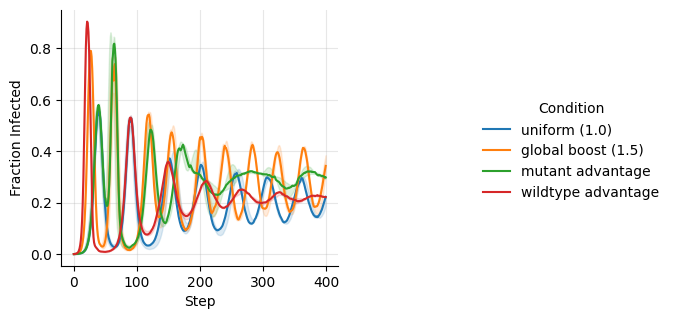

In [7]:
with tp.teed(
    sns.relplot,
    data=df,
    x="Step",
    y="Total_Infected",
    hue="Condition",
    kind="line",
    estimator=np.median,
    errorbar=("pi", 100),
    err_kws=dict(alpha=0.15),
    facet_kws=dict(margin_titles=True),
    teeplot_outattrs={"what": "total-infected"},
    teeplot_subdir=teeplot_subdir,
) as g:
    for ax in g.axes.flat:
        ax.grid(True, alpha=0.3)
    g.set_axis_labels("Step", "Fraction Infected")
    g.figure.set_size_inches(w=5, h=3)
    sns.move_legend(
        g, "center left", bbox_to_anchor=(0.95, 0.5), frameon=False
    )


## Per-Strain Prevalence Across Conditions

Per-strain trajectories reveal how scalar versus vector transmissibility
reshape competition between strains.


teeplots/2026-06-17-strain-transmissibility/col=condition+hue=strain+kind=line+viz=relplot+what=per-strain+x=step+y=prevalence+ext=.pdf
teeplots/2026-06-17-strain-transmissibility/col=condition+hue=strain+kind=line+viz=relplot+what=per-strain+x=step+y=prevalence+ext=.png


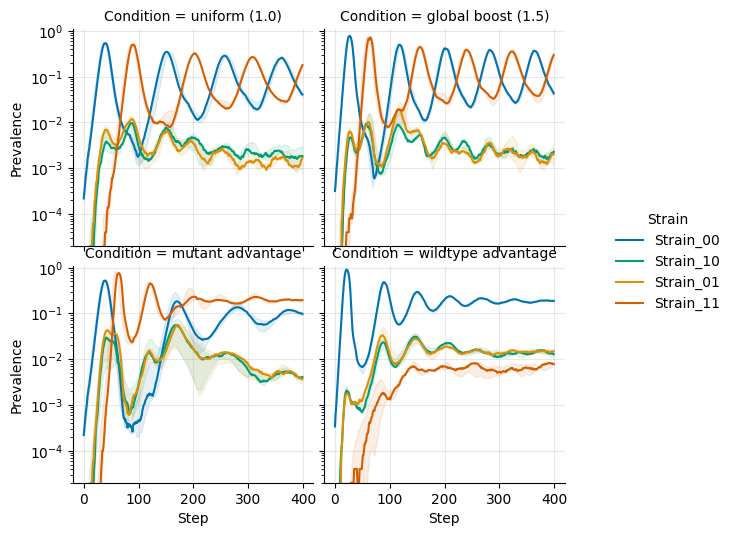

In [8]:
strain_df = (
    df.filter(regex="Step|Seed|Condition|Strain", axis=1)
    .melt(
        id_vars=["Step", "Seed", "Condition"],
        var_name="Strain",
        value_name="Prevalence",
    )
    .astype({"Step": int, "Strain": str, "Prevalence": float})
)
palette = dict(
    zip(
        sorted(strain_df["Strain"].unique()),
        sns.color_palette("colorblind", strain_df["Strain"].nunique()),
    )
)

with tp.teed(
    sns.relplot,
    data=strain_df,
    x="Step",
    y="Prevalence",
    hue="Strain",
    col="Condition",
    col_wrap=2,
    kind="line",
    estimator=np.median,
    errorbar=("pi", 100),
    err_kws=dict(alpha=0.1),
    palette=palette,
    facet_kws=dict(margin_titles=True),
    teeplot_outattrs={"what": "per-strain"},
    teeplot_subdir=teeplot_subdir,
) as g:
    for ax in g.axes.flat:
        ax.grid(True, alpha=0.3)
    g.set(yscale="log", ylim=(1 / POP_SIZE, 1.1))
    g.figure.set_size_inches(w=6, h=5)
    sns.move_legend(
        g, "center left", bbox_to_anchor=(0.95, 0.5), frameon=False
    )


## Sanity Check: Endpoint Prevalence

A succinct numerical confirmation that scalar transmissibility is monotonic in
overall prevalence, and that the per-strain vectors shift which strains
dominate. Reported as the median final-step prevalence across replicates.


In [9]:
summary = (
    df.groupby("Condition")
    .apply(
        lambda g: g[g["Step"] == g["Step"].max()].median(numeric_only=True),
        include_groups=False,
    )
    .filter(regex="Total_Infected|Strain")
    .round(4)
)
summary


,Total_Infected,Strain_00,Strain_10,Strain_01,Strain_11
Condition,,,,,
global boost (1.5),0.3429,0.0432,0.0023,0.0020,0.2954
mutant advantage,0.2979,0.0973,0.0040,0.0037,0.1940
uniform (1.0),0.2226,0.0409,0.0018,0.0017,0.1802
wildtype advantage,0.2217,0.1865,0.0129,0.0148,0.0078
